<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/Regularization_1_Parameter_Penalties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization I — Parameter Norm Penalties (hands-on)

**Companion notebook to the "Beyond the penalty" playground.**
Every concept from the study page, turned into short, runnable experiments.

Covered here: the overfitting gap · **L² weight decay** (from scratch + closed form) · **ridge & correlated features** · **L¹ / LASSO sparsity** · **L¹ vs L² vs Elastic Net** · **penalties as constraints** (choosing α by cross-validation) · **max-norm** (projected gradient) · **under-constrained** problems (separable logistic regression, p ≫ n).

> Runs anywhere with **numpy · scikit-learn · matplotlib** (all preinstalled on Google Colab). No datasets are downloaded — everything is synthetic or bundled, so every cell just works.


In [ ]:
# Setup — all preinstalled on Colab
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
print("numpy", np.__version__)

numpy 2.4.4


## 1 · The problem regularization solves: the train–validation gap

A flexible model (here a degree-12 polynomial) can drive its **training** error to almost zero while doing badly on new points. Adding an L² penalty (`alpha`) tames the wiggle.

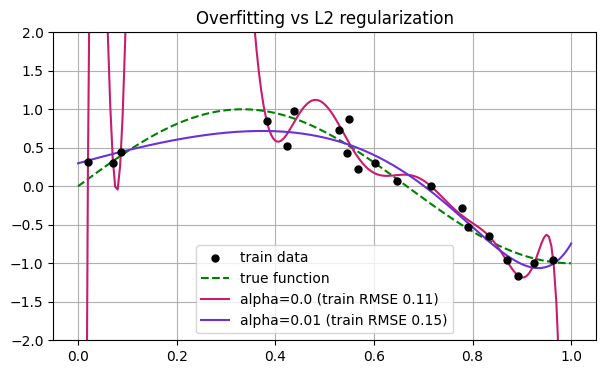

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

def true_f(x): return np.sin(1.5 * np.pi * x)
n = 20
Xtr = np.sort(np.random.rand(n)); ytr = true_f(Xtr) + 0.15 * np.random.randn(n)
Xte = np.linspace(0, 1, 200)

plt.scatter(Xtr, ytr, c='k', s=25, zorder=3, label='train data')
plt.plot(Xte, true_f(Xte), 'g--', label='true function')
for a, c in [(0.0, '#C81C6E'), (1e-2, '#6C30D9')]:
    m = make_pipeline(PolynomialFeatures(12), Ridge(alpha=a)).fit(Xtr[:, None], ytr)
    tr = np.sqrt(mean_squared_error(ytr, m.predict(Xtr[:, None])))
    plt.plot(Xte, m.predict(Xte[:, None]), color=c, label=f'alpha={a} (train RMSE {tr:.2f})')
plt.ylim(-2, 2); plt.legend(); plt.title('Overfitting vs L2 regularization'); plt.show()

## 2 · L² weight decay — from scratch, and the closed form

Minimising  ½‖Xw−y‖²/n + (α/2)‖w‖²  by gradient descent gives the weight-decay update
`w ← w − lr·[ (1/n)Xᵀ(Xw−y) + α·w ]`.
Its exact optimum is the ridge closed form  **w̃ = (XᵀX + nαI)⁻¹ Xᵀy** — we check they agree, then watch ‖w‖ shrink as α grows.

gradient descent vs closed form,  ||w_gd - w_cf|| = 2.1892732602054695e-15


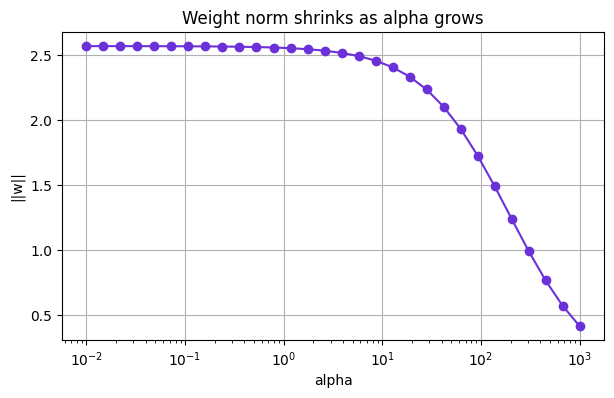

In [ ]:
n, d = 200, 10
Xr = np.random.randn(n, d); w_true = np.random.randn(d)
yr = Xr @ w_true + 0.5 * np.random.randn(n)

def gd_ridge(X, y, alpha, lr=0.05, steps=3000):
    w = np.zeros(X.shape[1]); n = len(y)
    for _ in range(steps):
        w -= lr * (X.T @ (X @ w - y) / n + alpha * w)
    return w

alpha = 0.5
w_gd = gd_ridge(Xr, yr, alpha)
w_cf = np.linalg.solve(Xr.T @ Xr + n * alpha * np.eye(d), Xr.T @ yr)   # closed form
print("gradient descent vs closed form,  ||w_gd - w_cf|| =", np.linalg.norm(w_gd - w_cf))

alphas = np.logspace(-2, 3, 30)
norms = [np.linalg.norm(Ridge(alpha=a, fit_intercept=False).fit(Xr, yr).coef_) for a in alphas]
plt.semilogx(alphas, norms, 'o-', color='#6C30D9')
plt.xlabel('alpha'); plt.ylabel('||w||'); plt.title('Weight norm shrinks as alpha grows'); plt.show()

## 3 · Ridge & correlated features (the Hessian story)

When two features are almost duplicates, `XᵀX` is nearly singular (huge condition number) and plain least squares gives wild, opposite-signed coefficients. The α·I term fixes the ill-conditioning — pulling the flat, redundant directions toward zero while barely touching the well-determined ones.

condition number of X^T X: 35558.1
OLS  coefs of the two duplicates (unstable): [ 2.4  -1.38]
Ridge coefs of the two duplicates (stable):  [0.51 0.5 ]


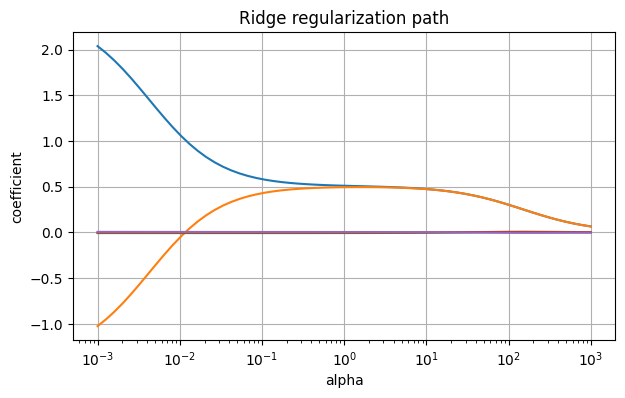

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
n = 100
x1 = np.random.randn(n); x2 = x1 + 0.01 * np.random.randn(n)          # near-duplicate
X = np.c_[x1, x2, np.random.randn(n, 3)]
y = 3 * x1 - 2 * x2 + 0.1 * np.random.randn(n)

print("condition number of X^T X:", f"{np.linalg.cond(X.T @ X):.1f}")
ols = LinearRegression(fit_intercept=False).fit(X, y).coef_
rid = Ridge(alpha=1.0, fit_intercept=False).fit(X, y).coef_
print("OLS  coefs of the two duplicates (unstable):", np.round(ols[:2], 2))
print("Ridge coefs of the two duplicates (stable): ", np.round(rid[:2], 2))

alphas = np.logspace(-3, 3, 60)
coefs = np.array([Ridge(alpha=a, fit_intercept=False).fit(X, y).coef_ for a in alphas])
for j in range(X.shape[1]): plt.semilogx(alphas, coefs[:, j])
plt.xlabel('alpha'); plt.ylabel('coefficient'); plt.title('Ridge regularization path'); plt.show()

## 4 · L¹ / LASSO — sparsity and feature selection

With many irrelevant inputs, L¹ drives useless coefficients to **exactly zero**, recovering the true handful of predictive features. Increasing α keeps fewer and fewer features.

true informative features: [12, 14, 16, 25, 43]
LASSO-selected features:   [12, 14, 16, 25, 35, 43]


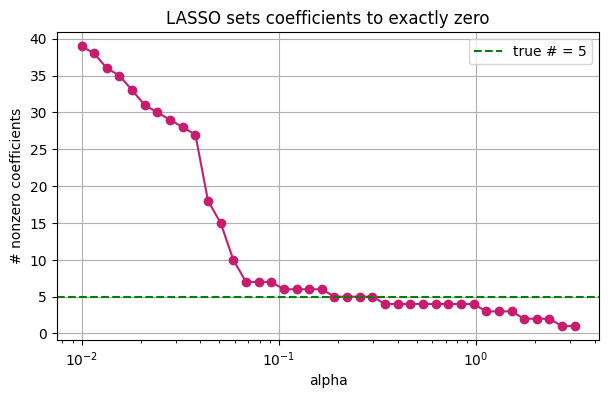

In [ ]:
from sklearn.linear_model import Lasso
n, d, k = 100, 50, 5
XL = np.random.randn(n, d)
true_idx = np.sort(np.random.choice(d, k, replace=False))
wt = np.zeros(d); wt[true_idx] = np.random.randn(k) * 3
yL = XL @ wt + 0.5 * np.random.randn(n)

las = Lasso(alpha=0.1).fit(XL, yL)
sel = np.where(np.abs(las.coef_) > 1e-6)[0]
print("true informative features:", true_idx.tolist())
print("LASSO-selected features:  ", sel.tolist())

alphas = np.logspace(-2, 0.5, 40)
nnz = [np.sum(np.abs(Lasso(alpha=a, max_iter=5000).fit(XL, yL).coef_) > 1e-6) for a in alphas]
plt.semilogx(alphas, nnz, 'o-', color='#C81C6E')
plt.axhline(k, color='g', ls='--', label=f'true # = {k}')
plt.xlabel('alpha'); plt.ylabel('# nonzero coefficients'); plt.legend()
plt.title('LASSO sets coefficients to exactly zero'); plt.show()

## 5 · L¹ vs L² vs Elastic Net (grouped correlated features)

When features arrive in correlated **groups**, pure LASSO keeps one member at random and zeros the rest; Ridge keeps them all but shrinks; **Elastic Net** (L¹+L²) keeps the group together *and* stays sparse across groups.

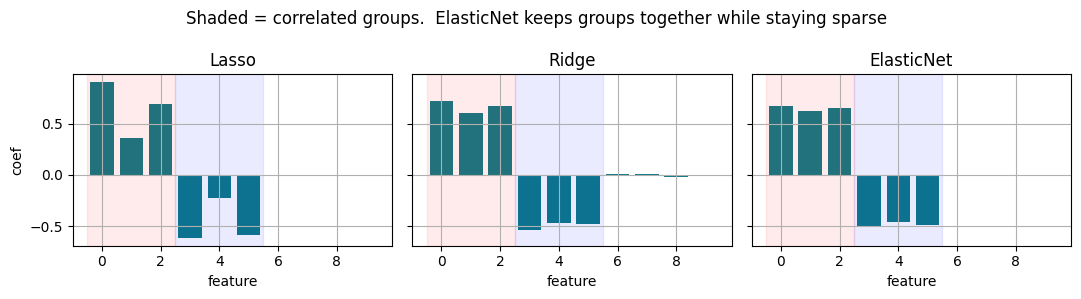

In [ ]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
n = 120
base = np.random.randn(n, 2)
g1 = base[:, 0:1] + 0.05 * np.random.randn(n, 3)      # correlated group A (cols 0-2)
g2 = base[:, 1:2] + 0.05 * np.random.randn(n, 3)      # correlated group B (cols 3-5)
X = np.hstack([g1, g2, np.random.randn(n, 4)])        # + 4 pure-noise features
y = 2 * base[:, 0] - 1.5 * base[:, 1] + 0.2 * np.random.randn(n)

models = {'Lasso': Lasso(alpha=0.05),
          'Ridge': Ridge(alpha=1.0),
          'ElasticNet': ElasticNet(alpha=0.05, l1_ratio=0.5)}
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    m.fit(X, y)
    ax.bar(range(X.shape[1]), m.coef_, color='#0F7C87')
    ax.axvspan(-0.5, 2.5, alpha=.08, color='red'); ax.axvspan(2.5, 5.5, alpha=.08, color='blue')
    ax.set_title(name); ax.set_xlabel('feature')
axes[0].set_ylabel('coef')
plt.suptitle('Shaded = correlated groups.  ElasticNet keeps groups together while staying sparse')
plt.tight_layout(); plt.show()

## 6 · Penalties as constraints → choosing α by cross-validation

Turning α up shrinks the "ball" the weights may live in. You don't guess α in practice — you **cross-validate** it on a log grid and keep the validation-optimal value.

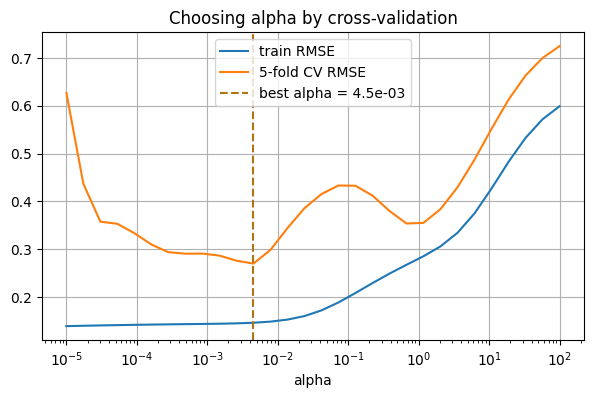

cross-validated best alpha: 4.52e-03


In [ ]:
from sklearn.model_selection import validation_curve
pipe = make_pipeline(PolynomialFeatures(12), Ridge())
alphas = np.logspace(-5, 2, 30)
tr_sc, va_sc = validation_curve(pipe, Xtr[:, None], ytr, param_name='ridge__alpha',
                                param_range=alphas, scoring='neg_root_mean_squared_error', cv=5)
tr, va = -tr_sc.mean(1), -va_sc.mean(1)
best = alphas[np.argmin(va)]
plt.semilogx(alphas, tr, label='train RMSE')
plt.semilogx(alphas, va, label='5-fold CV RMSE')
plt.axvline(best, color='#B27412', ls='--', label=f'best alpha = {best:.1e}')
plt.xlabel('alpha'); plt.legend(); plt.title('Choosing alpha by cross-validation'); plt.show()
print("cross-validated best alpha:", f"{best:.2e}")

## 7 · Max-norm constraint via projected gradient (reprojection)

Instead of a soft penalty, hard-cap the weights: take a normal step, then if ‖w‖ exceeds a radius `c`, project it straight back onto the ball. The norm is held at the boundary — the reprojection idea behind max-norm regularization.

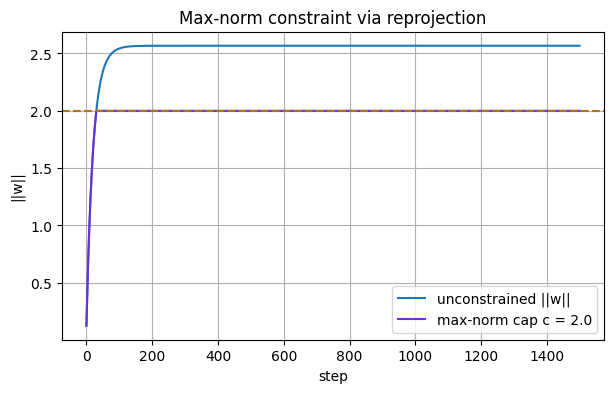

In [ ]:
def gd_maxnorm(X, y, c, lr=0.05, steps=1500):
    w = np.zeros(X.shape[1]); n = len(y); hist = []
    for _ in range(steps):
        w -= lr * (X.T @ (X @ w - y) / n)
        nrm = np.linalg.norm(w)
        if nrm > c: w *= c / nrm                 # project onto the ball of radius c
        hist.append(np.linalg.norm(w))
    return hist

h_free = gd_maxnorm(Xr, yr, c=1e9)               # effectively unconstrained
h_cap  = gd_maxnorm(Xr, yr, c=2.0)
plt.plot(h_free, label='unconstrained ||w||')
plt.plot(h_cap, color='#6C30D9', label='max-norm cap c = 2.0')
plt.axhline(2.0, color='#B27412', ls='--')
plt.xlabel('step'); plt.ylabel('||w||'); plt.legend()
plt.title('Max-norm constraint via reprojection'); plt.show()

## 8 · Under-constrained problems

**(a) Separable data.** Logistic regression on perfectly separable classes wants to send its weights to infinity — the weaker the regularization (larger `C = 1/α`), the bigger ‖w‖ grows. L² keeps it finite.

**(b) p ≫ n.** With more features than samples there is no unique least-squares answer; ridge picks a stable minimum-norm solution.

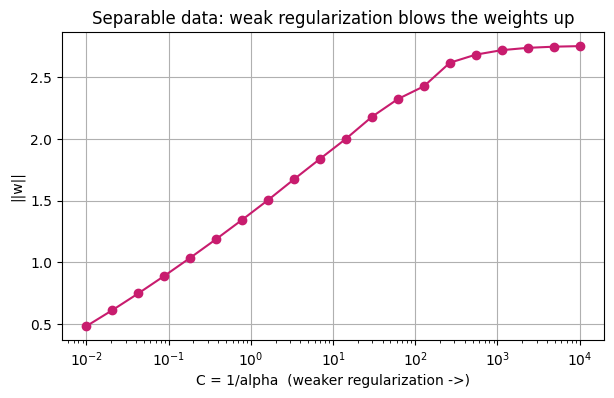

||w|| at strong reg (C=0.01): 0.48   at weak reg (C=1e4): 2.75
p>>n (200 features, 15 samples) solved with ridge — train RMSE 0.017, ||w|| 0.93


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs

Xb, yb = make_blobs(n_samples=100, centers=[[-3, -3], [3, 3]], cluster_std=0.6, random_state=0)
Cs = np.logspace(-2, 4, 20)                       # large C = weak regularization
norms = [np.linalg.norm(LogisticRegression(C=c, max_iter=5000).fit(Xb, yb).coef_) for c in Cs]
plt.semilogx(Cs, norms, 'o-', color='#C81C6E')
plt.xlabel('C = 1/alpha  (weaker regularization ->)'); plt.ylabel('||w||')
plt.title('Separable data: weak regularization blows the weights up'); plt.show()
print(f"||w|| at strong reg (C=0.01): {norms[0]:.2f}   at weak reg (C=1e4): {norms[-1]:.2f}")

# (b) p >> n
n, p = 15, 200
Xw = np.random.randn(n, p); w0 = np.zeros(p); w0[:3] = [2, -3, 1.5]
yw = Xw @ w0 + 0.1 * np.random.randn(n)
rid = Ridge(alpha=1.0, fit_intercept=False).fit(Xw, yw)
print(f"p>>n ({p} features, {n} samples) solved with ridge — "
      f"train RMSE {np.sqrt(np.mean((Xw @ rid.coef_ - yw) ** 2)):.3f}, ||w|| {np.linalg.norm(rid.coef_):.2f}")

## Recap

| Concept | Tool used here | What you saw |
|---|---|---|
| Overfitting gap | `Ridge` + polynomials | α tames a degree-12 wiggle |
| L² weight decay | from-scratch GD | matches `(XᵀX+nαI)⁻¹Xᵀy`; ‖w‖ ↓ as α ↑ |
| Ridge & Hessian | correlated features | α·I fixes ill-conditioning |
| L¹ sparsity | `Lasso` | exact zeros recover the true support |
| L¹ vs L² vs EN | `ElasticNet` | EN keeps correlated groups together |
| Penalty ↔ constraint | `validation_curve` | pick α by cross-validation |
| Max-norm | projected GD | ‖w‖ hard-capped at `c` |
| Under-constrained | separable / p≫n | weak reg ⇒ ‖w‖→∞; ridge stabilises |

**Deep-learning tie-in:** in PyTorch the same L² is one argument — `torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)`. Everything above is what that single knob is doing under the hood.
